In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from data.loader import load_openml_data, preprocess_after_split
from data.missing_data import generate_mcar, generate_mar1, generate_mar2, generate_mnar
from models.fista_lr import LogisticRegression
from models.unlabeled_lr import UnlabeledLogReg, run_naive, run_oracle, evaluate

## Preparing data

In [2]:
np.random.seed(1)

# loading Spambase dataset (OpenML ID = 44)
X, y = load_openml_data(data_id=44)

# splitting the data
X_train_raw, X_tmp, y_train, y_tmp = train_test_split(
    X, y, train_size=0.6, random_state=1
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=1
)

# preprocessing
X_train, X_valid, X_test = preprocess_after_split(X_train_raw, X_valid, X_test)

# generating missing target
y_mcar = generate_mcar(X_train_raw, y_train, c=0.3)
y_mar1 = generate_mar1(X_train_raw, y_train)
y_mar2 = generate_mar2(X_train_raw, y_train)
y_mnar = generate_mnar(X_train_raw, y_train, ratio=0.5)

print("Percentage of missing data in y_train")
print(f"MCAR: {(y_mcar == -1).mean():.2%}")
print(f"MAR1: {(y_mar1 == -1).mean():.2%}")
print(f"MAR2: {(y_mar2 == -1).mean():.2%}")
print(f"MNAR: {(y_mnar == -1).mean():.2%}")

Percentage of missing data in y_train
MCAR: 29.67%
MAR1: 46.99%
MAR2: 39.06%
MNAR: 62.93%


## FISTA Lasso Logistic Regression
Example usage of FISTA Lasso Logistic Regression on a dataset with no missing data in the target variable $y$.

In [3]:
# create and fit model
lr = LogisticRegression(lmbd=2, max_iter=1000, tol=1e-4)
lr.fit(X_train, y_train)

# predict
pred = lr.predict_proba(X_test) > 0.5

# measure balanced accuracy on test set
ba = balanced_accuracy_score(y_test, pred)
print(f"Balanced accuracy for test set and lambda = 2: {ba}")

Balanced accuracy for test set and lambda = 2: 0.9163833548650302


/Users/ola/projects/aml-project-1/src/models/fista_lr.py:194: RuntimeWarning: For lambda = 2, max_iter = 1000 and tol = 0.0001 the algorithm did not converge
  warnings.warn(


In [4]:
# hide convergance warnings
warnings.filterwarnings("ignore")

# find the best lambda based on balanced accuracy on validation set
lr_best = lr.validate(X_valid, y_valid, measure="bal_acc")

# predict using model with best lambda
pred = lr_best.predict_proba(X_test) > 0.5

# calculate balanced accuracy
ba = balanced_accuracy_score(y_test, pred)
print(f"Best lambda based on balanced accuracy on validation set: {lr_best.lmbd}")
print(f"Balanced accuracy on test set for optimized lambda: {ba}")

Best lambda based on balanced accuracy on validation set: 0.1
Balanced accuracy on test set for optimized lambda: 0.9149093240342305


In [5]:
print(f"Intercept for model with best lambda {lr_best.b0}")
print(f"Beta: {lr_best.beta}")

Intercept for model with best lambda -8.131259417388646
Beta: word_freq_make                -0.121591
word_freq_address             -0.192710
word_freq_all                  0.061026
word_freq_3d                   1.301095
word_freq_our                  0.251937
word_freq_over                 0.168296
word_freq_remove               0.737516
word_freq_internet             0.239959
word_freq_order                0.303090
word_freq_mail                 0.044602
word_freq_receive             -0.109106
word_freq_will                -0.129134
word_freq_people               0.016688
word_freq_report               0.019471
word_freq_addresses            0.579326
word_freq_free                 1.089574
word_freq_business             0.333795
word_freq_email                0.049947
word_freq_you                  0.185109
word_freq_credit               0.508719
word_freq_your                 0.248659
word_freq_font                 0.303107
word_freq_000                  0.687089
word_freq_money   

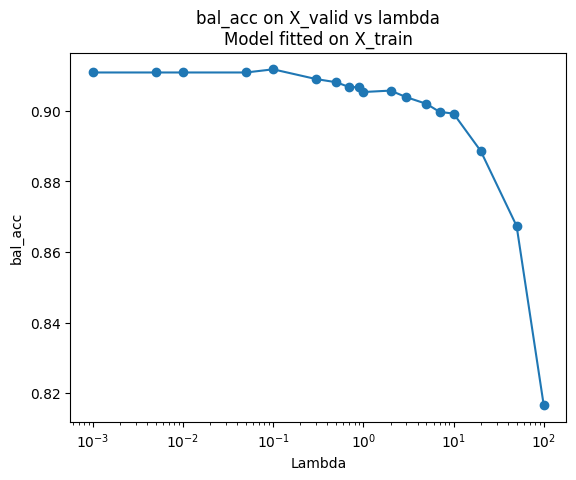

In [6]:
# Plot how values of selected measure on validation set change with lambda
lr.plot("bal_acc")

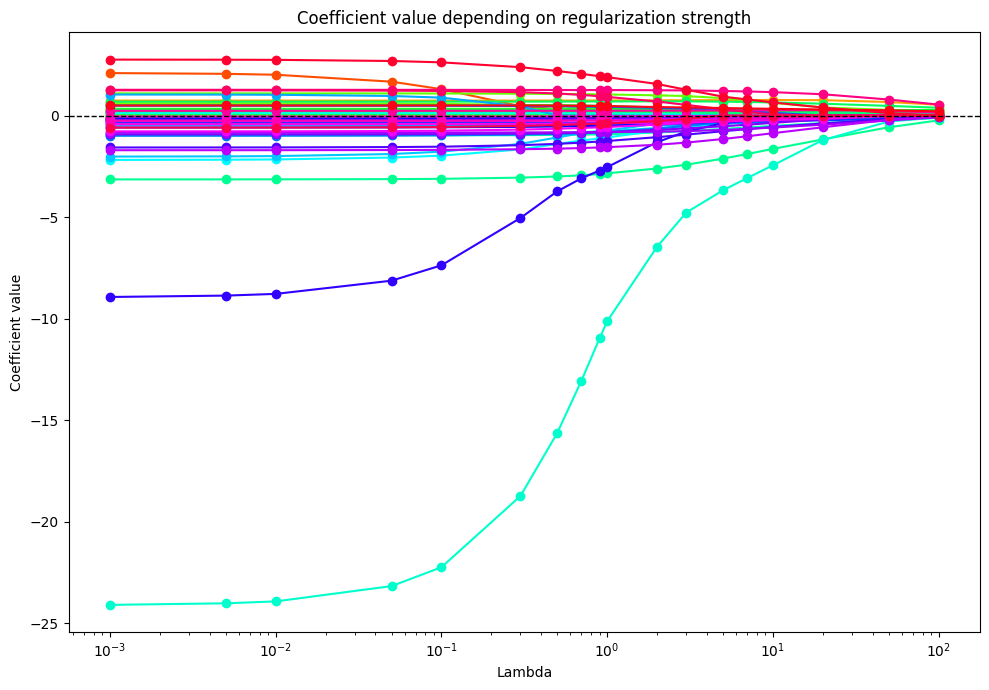

In [7]:
# profile plot - shows how regularization strength lambda affects the values of beta^
lr.plot_coefficients()

## UnlabeledLogReg

In [8]:
# create models and select method of imputation
ulr1 = UnlabeledLogReg(completion="label_prop_cne", lp_kernel="knn", lp_n_neighbors=5)
ulr2 = UnlabeledLogReg(completion="sportisse_em")

# fit model using y_mnar
ulr1 = ulr1.fit(X_train=X_train, y_obs=y_mnar, X_valid=X_valid, y_valid=y_valid)
ulr2 = ulr2.fit(X_train=X_train, y_obs=y_mnar, X_valid=X_valid, y_valid=y_valid)

# predict
y_pred1 = ulr1.predict(X_test)
y_pred2 = ulr2.predict(X_test)

# compute balanced accuracy
ba_naive = run_naive(
    X_train=X_train,
    y_obs=y_mnar,
    X_valid=X_valid,
    y_valid=y_valid,
    X_test=X_test,
    y_test=y_test,
    measure="bal_acc",
)["balanced_accuracy"]
ba_oracle = run_oracle(
    X_train=X_train,
    y_true_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    X_test=X_test,
    y_test=y_test,
    measure="bal_acc",
)["balanced_accuracy"]
ba1 = balanced_accuracy_score(y_test, y_pred1)
ba2 = balanced_accuracy_score(y_test, y_pred2)

print(f"Balanced accuracy for model trained on full y_train: {ba_naive}")
print(f"Balanced accuracy for model trained on y_mnar and naive approach: {ba_naive}")
print(f"Balanced accuracy for model trained on y_mnar and imputation label_prop_cne: {ba1}")
print(f"Balanced accuracy for model trained on y_mnar and imputation sportisse: {ba2}")

Balanced accuracy for model trained on full y_train: 0.8652852383218875
Balanced accuracy for model trained on y_mnar and naive approach: 0.8652852383218875
Balanced accuracy for model trained on y_mnar and imputation label_prop_cne: 0.7332004196252513
Balanced accuracy for model trained on y_mnar and imputation sportisse: 0.5052356020942408
